# Actividad Práctica 3 — Del EDA al modelo: preparación, modelado básico y publicación

---

## Caso y continuidad con la Actividad 2

Se trabaja con el mismo caso y dataset de la Actividad 2: la detección temprana de diabetes tipo 2 a partir de variables clínicas y biométricas del **PIMA Indians Diabetes Database** (Kaggle, 768 instancias × 9 columnas).

**Pregunta principal.** ¿Qué variables muestran una asociación más marcada con la presencia de diabetes y permiten construir un modelo predictivo básico?

**Hipótesis (formuladas en AP2).**
- **H1 (Glucosa).** La concentración de glucosa en plasma es mayor en pacientes con diagnóstico positivo de diabetes.
- **H2 (IMC).** Existe una correlación positiva entre el IMC y la presencia de diabetes.

**Link del dataset:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database


## Librerías utilizadas

Se trabaja con **pandas**, **numpy** y **matplotlib** (continuidad con AP2) y se incorpora **scikit-learn** para el modelado y la evaluación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42  # para reproducibilidad

---
## 2.3 Recolección y preparación de datos

### 2.3.1 Carga del dataset y tratamiento de faltantes disimulados

Se recarga el dataset descargado de Kaggle. Como se identificó en la AP2, cinco columnas (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contienen ceros fisiológicamente imposibles que funcionan como faltantes disimulados. Se reemplazan por `NaN` para poder imputarlos correctamente.

In [2]:
# Carga del dataset
df = pd.read_csv("diabetes.csv")

# Conversión de ceros fisiológicamente imposibles a NaN (decisión heredada de AP2)
cols_con_ceros_invalidos = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_con_ceros_invalidos] = df[cols_con_ceros_invalidos].replace(0, np.nan)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nFaltantes por columna:")
print(df.isna().sum())

Dimensiones: 768 filas x 9 columnas

Faltantes por columna:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 2.3.2 Imputación de nulos por mediana de grupo

Se imputan los valores faltantes con la mediana de cada columna calculada **por grupo de `Outcome`** (una mediana para las pacientes con diabetes y otra para las pacientes sin diabetes). Se elige la mediana sobre la media por ser robusta a outliers, y la versión por grupo sobre la global porque los dos grupos tienen distribuciones distintas (lo mostró el EDA de AP2). La limitación metodológica de esta decisión (fuga de información hacia el test) se discute en la interpretación final.

In [3]:
# Imputación de nulos: mediana por grupo de Outcome
for col in cols_con_ceros_invalidos:
    df[col] = df.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

# Verificación: ya no debería haber faltantes
print("Faltantes después de la imputación:")
print(df.isna().sum())
print(f"\nFilas conservadas: {df.shape[0]} (sin pérdida de datos)")

Faltantes después de la imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Filas conservadas: 768 (sin pérdida de datos)


### 2.3.3 Variable derivada: `Glucose_Category` (criterio ADA)

Se crea una variable categórica derivada de `Glucose` siguiendo los puntos de corte de la **American Diabetes Association (ADA)** para glucemia en ayunas:

- **Normal:** < 100 mg/dL
- **Prediabetes:** 100–125 mg/dL
- **Diabetes:** ≥ 126 mg/dL

Esta categorización transforma información continua en una variable interpretable clínicamente y permite caracterizar de forma directa la distribución de riesgo en el dataset.

In [4]:
# Variable derivada: categorización ADA de glucosa
def categorizar_glucosa(valor):
    if valor < 100:
        return "Normal"
    elif valor < 126:
        return "Prediabetes"
    else:
        return "Diabetes"

df["Glucose_Category"] = df["Glucose"].apply(categorizar_glucosa)

# Tabla de contingencia: Glucose_Category vs Outcome
tabla = pd.crosstab(df["Glucose_Category"], df["Outcome"],
                    margins=True, margins_name="Total")
tabla.columns = ["Sin diabetes", "Con diabetes", "Total"]
print("Distribución de Glucose_Category vs Outcome:")
print(tabla)
print("\nProporción de positivos por categoría:")
prop = (df.groupby("Glucose_Category")["Outcome"].mean() * 100).round(1)
print(prop.astype(str) + " %")

Distribución de Glucose_Category vs Outcome:
                  Sin diabetes  Con diabetes  Total
Glucose_Category                                   
Diabetes                   121           178    299
Normal                     178            14    192
Prediabetes                201            76    277
Total                      500           268    768

Proporción de positivos por categoría:
Glucose_Category
Diabetes       59.5 %
Normal          7.3 %
Prediabetes    27.4 %
Name: Outcome, dtype: object


**Observación.** Como era esperable por construcción, la categoría "Diabetes" según ADA concentra la mayor proporción de positivos reales. Esta variable derivada se mantiene en el dataset con fines descriptivos, pero **no se incluye en `X` para el modelo**, porque está definida directamente a partir de `Glucose` (que sí entra en `X`) y agregarla generaría redundancia y colinealidad perfecta.

### 2.3.4 Estandarización de variables numéricas

Se estandarizan las 8 variables predictoras con `StandardScaler` (z-score: media 0, desvío 1) porque están en escalas muy distintas (por ejemplo `Pregnancies` toma valores entre 0 y 17, mientras que `Insulin` llega a 846). Esto permite que los coeficientes del modelo sean comparables entre sí (necesario para discutir H1 y H2) y evita que la regularización por defecto de scikit-learn castigue de forma desigual a variables de distinta escala.

In [5]:
# Variables predictoras (las 8 numéricas originales)
features_numericas = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                       "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

# Estandarización (z-score)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_numericas] = scaler.fit_transform(df[features_numericas])

# Verificación: las variables estandarizadas tienen media ≈ 0 y desvío ≈ 1
print("Verificación de estandarización (media y desvío de cada variable):")
print(df_scaled[features_numericas].agg(["mean", "std"]).round(3))

Verificación de estandarización (media y desvío de cada variable):
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin    BMI  \
mean       -0.000    0.000         -0.000          0.000   -0.000  0.000   
std         1.001    1.001          1.001          1.001    1.001  1.001   

      DiabetesPedigreeFunction    Age  
mean                     0.000  0.000  
std                      1.001  1.001  


---
## 2.4 Modelado básico

### 2.4.1 Selección de variables (X e y)

- **Variable objetivo (y):** `Outcome` (binaria: 0 = sin diabetes, 1 = con diabetes).
- **Predictoras (X):** las 8 variables numéricas estandarizadas.
- **Modelo a aplicar:** **regresión logística** (clasificación binaria, modelo básico interpretable).

In [6]:
# Definición de X e y
X = df_scaled[features_numericas]
y = df_scaled["Outcome"]

print(f"X (predictoras): {X.shape}")
print(f"y (objetivo): {y.shape}")
print(f"\nDistribución de clases en y:")
print(y.value_counts())
print(f"Proporción de positivos: {(y.mean()*100):.1f} %")

X (predictoras): (768, 8)
y (objetivo): (768,)

Distribución de clases en y:
Outcome
0    500
1    268
Name: count, dtype: int64
Proporción de positivos: 34.9 %


### 2.4.2 Split train/test

Se divide el dataset en **80 % entrenamiento** y **20 % test**, con `stratify=y` para mantener la misma proporción de positivos en ambos subconjuntos (~35 %), y `random_state=42` para reproducibilidad.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"\nProporción de positivos en train: {(y_train.mean()*100):.1f} %")
print(f"Proporción de positivos en test:  {(y_test.mean()*100):.1f} %")

X_train: (614, 8)   y_train: (614,)
X_test:  (154, 8)   y_test:  (154,)

Proporción de positivos en train: 34.9 %
Proporción de positivos en test:  35.1 %


### 2.4.3 Entrenamiento del modelo

Se entrena una **regresión logística** con los parámetros por defecto de scikit-learn (`max_iter=1000` para asegurar convergencia).

In [8]:
modelo = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo.fit(X_train, y_train)

# Coeficientes del modelo (sobre variables estandarizadas, por lo que son comparables entre sí)
coefs = pd.DataFrame({
    "Variable": features_numericas,
    "Coeficiente": modelo.coef_[0].round(3)
}).sort_values("Coeficiente", key=abs, ascending=False)

print("Coeficientes de la regresión logística (orden de magnitud):")
print(coefs.to_string(index=False))
print(f"\nIntercepto: {modelo.intercept_[0]:.3f}")

Coeficientes de la regresión logística (orden de magnitud):
                Variable  Coeficiente
                 Glucose        0.948
                 Insulin        0.668
                     BMI        0.470
             Pregnancies        0.343
           SkinThickness        0.292
DiabetesPedigreeFunction        0.175
                     Age        0.159
           BloodPressure       -0.004

Intercepto: -0.867


### 2.4.4 Evaluación: accuracy y matriz de confusión

Se evalúa el modelo en el conjunto de **test** (datos no vistos durante el entrenamiento), reportando la métrica solicitada por la consigna (`Accuracy`) y la `Matriz de Confusión`. Adicionalmente se muestra el `classification_report` con precision, recall y F1 por clase, que es útil para detectar desbalance en el rendimiento.

In [9]:
# Predicciones sobre el conjunto de test
y_pred = modelo.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (test): {acc:.3f}  ({acc*100:.1f} %)")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print(f"\nMatriz de confusión:")
print(cm)
print("\n          Pred 0   Pred 1")
print(f"Real 0    {cm[0,0]:>6}   {cm[0,1]:>6}")
print(f"Real 1    {cm[1,0]:>6}   {cm[1,1]:>6}")

# Reporte de clasificación (precision, recall, F1)
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Sin diabetes (0)", "Con diabetes (1)"]))

Accuracy (test): 0.708  (70.8 %)

Matriz de confusión:
[[79 21]
 [24 30]]

          Pred 0   Pred 1
Real 0        79       21
Real 1        24       30

Classification report:
                  precision    recall  f1-score   support

Sin diabetes (0)       0.77      0.79      0.78       100
Con diabetes (1)       0.59      0.56      0.57        54

        accuracy                           0.71       154
       macro avg       0.68      0.67      0.67       154
    weighted avg       0.70      0.71      0.71       154



### 2.4.5 Visualización de la matriz de confusión

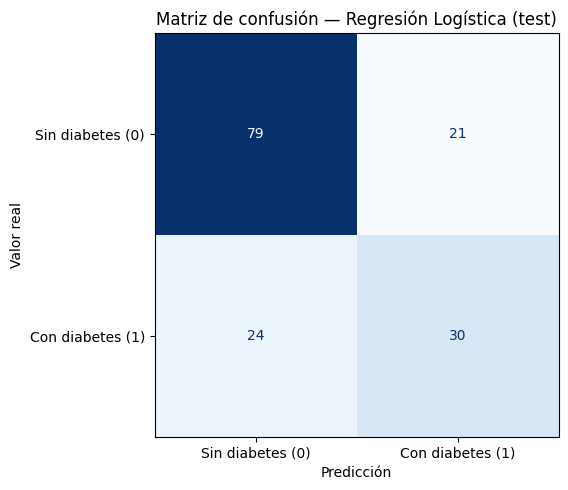

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Sin diabetes (0)", "Con diabetes (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de confusión — Regresión Logística (test)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

### 2.4.6 Interpretación de los resultados

**Lectura de las métricas.** La regresión logística alcanza una accuracy de **70,8 %** en el conjunto de test (109/154 casos clasificados correctamente). La matriz de confusión muestra que el modelo identifica mejor a la clase mayoritaria (recall de "sin diabetes" = 0,79) que a la minoritaria (recall de "con diabetes" = 0,56), perdiendo **24 de 54 pacientes positivos** (falsos negativos). Esta asimetría es esperable por dos razones: (a) el dataset está desbalanceado (~35 % de positivos), y (b) en clasificación con umbral 0,5 por defecto, el modelo tiende a favorecer la clase mayoritaria.

**Limitaciones observadas.** El modelo es simple (regresión logística sin ajuste de hiperparámetros) y no incorpora interacciones entre variables. La imputación por mediana de grupo se calculó sobre todo el dataset, lo que introduce una pequeña fuga de información hacia el split de test. En diagnóstico médico la accuracy global es una métrica engañosa cuando hay desbalance: el recall sobre la clase positiva (0,56) sería más crítico de optimizar, porque el costo de un falso negativo (no detectar diabetes) suele ser mayor que el de un falso positivo.

**Qué cambiaría con más datos / variables.** (1) Aplicar técnicas para clases desbalanceadas (`class_weight="balanced"`, SMOTE o ADASYN, en línea con Tasin et al. 2023), priorizando recall sobre la clase positiva. (2) Comparar con modelos no lineales (random forest, gradient boosting) que Shaukat et al. (2023) reportan con mejor desempeño sobre este mismo dataset. (3) Sumar variables externas (hábitos alimentarios, actividad física, historia familiar detallada) que la base PIMA no incluye.

**Relación con las hipótesis de AP2.** Los resultados **apoyan H1 (Glucosa) y H2 (IMC)**: sobre variables estandarizadas (coeficientes comparables entre sí), `Glucose` es la variable de mayor magnitud (β = 0,948) y `BMI` aparece tercera (β = 0,470). Ahora `Insulin` (β = 0,668) supera a `BMI`, cuando en el EDA original tenía menor correlación con `Outcome` (r ≈ 0,30); el cambio se explica probablemente porque la imputación rellenó los 374 valores faltantes de `Insulin`, reduciendo el ruido y aumentando su poder predictivo en el modelo. Los hallazgos son consistentes con Tasin et al. (2023), que identifican a glucosa e IMC como las variables de mayor peso predictivo mediante técnicas de XAI.

**Limitaciones éticas y posibles sesgos.** El dataset proviene exclusivamente de mujeres adultas de la comunidad Akimel O'odham (PIMA), por lo que un modelo entrenado sobre estos datos **no es generalizable a otras poblaciones** sin recalibración. Aplicarlo a hombres, a otras etnias o a poblaciones con diferente exposición ambiental y alimentaria reproduciría sesgos de representación. Además, como se discutió en AP2 (Radin, 2017), la reutilización de estos datos sin consentimiento continuo de la comunidad de origen conlleva un problema ético no resuelto, independiente del rendimiento técnico del modelo.